In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

from scipy.stats import linregress

ModuleNotFoundError: No module named 'scipy'

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

from scipy.stats import linregress

In [2]:
project_path = Path.cwd().parent

raw_path = project_path / "data" / "raw"
processed_path = project_path / "data" / "processed"

fund_master = pd.read_csv(processed_path / "01_fund_master_clean.csv")
nav_history = pd.read_csv(processed_path / "02_nav_history_clean.csv")
performance = pd.read_csv(processed_path / "03_scheme_performance_clean.csv")
benchmark = pd.read_csv(raw_path / "benchmark_indices.csv")

print("Loaded Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\agraw\\OneDrive\\Desktop\\Bluestock_MF_Capstone\\data\\processed\\01_fund_master_clean.csv'

In [3]:
import os

project_path = Path.cwd().parent
processed_path = project_path / "data" / "processed"

print(os.listdir(processed_path))

['01_fund_master_cleaned.csv', '02_nav_history_cleaned.csv', '03_aum_by_fund_house_cleaned.csv', '04_monthly_sip_inflows_cleaned.csv', '05_category_inflows_cleaned.csv', '06_industry_folio_count_cleaned.csv', '07_scheme_performance_cleaned.csv', '08_investor_transactions_cleaned.csv', '09_portfolio_holdings_cleaned.csv', '10_benchmark_indices_cleaned.csv']


In [4]:
project_path = Path.cwd().parent

raw_path = project_path / "data" / "raw"
processed_path = project_path / "data" / "processed"

fund_master = pd.read_csv(processed_path / "01_fund_master_cleaned.csv")
nav_history = pd.read_csv(processed_path / "02_nav_history_cleaned.csv")
aum = pd.read_csv(processed_path / "03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(processed_path / "04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv(processed_path / "05_category_inflows_cleaned.csv")
folio = pd.read_csv(processed_path / "06_industry_folio_count_cleaned.csv")
performance = pd.read_csv(processed_path / "07_scheme_performance_cleaned.csv")
transactions = pd.read_csv(processed_path / "08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv(processed_path / "09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv(processed_path / "10_benchmark_indices_cleaned.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [7]:
# Sort values by fund and date
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Calculate daily return
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [9]:
# Calculate CAGR for each fund

cagr_data = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[nav_history["amfi_code"] == fund]

    start_nav = fund_data.iloc[0]["nav"]
    end_nav = fund_data.iloc[-1]["nav"]

    years = (
        (fund_data.iloc[-1]["date"] - fund_data.iloc[0]["date"]).days
    ) / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_data.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [10]:
# Risk-free rate (annual)
risk_free_rate = 0.065

# Convert annual risk-free rate to daily
daily_rf = risk_free_rate / 252

sharpe_list = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    volatility = fund_returns.std()

    sharpe = (
        (avg_return - daily_rf)
        / volatility
    ) * np.sqrt(252)

    sharpe_list.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [11]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


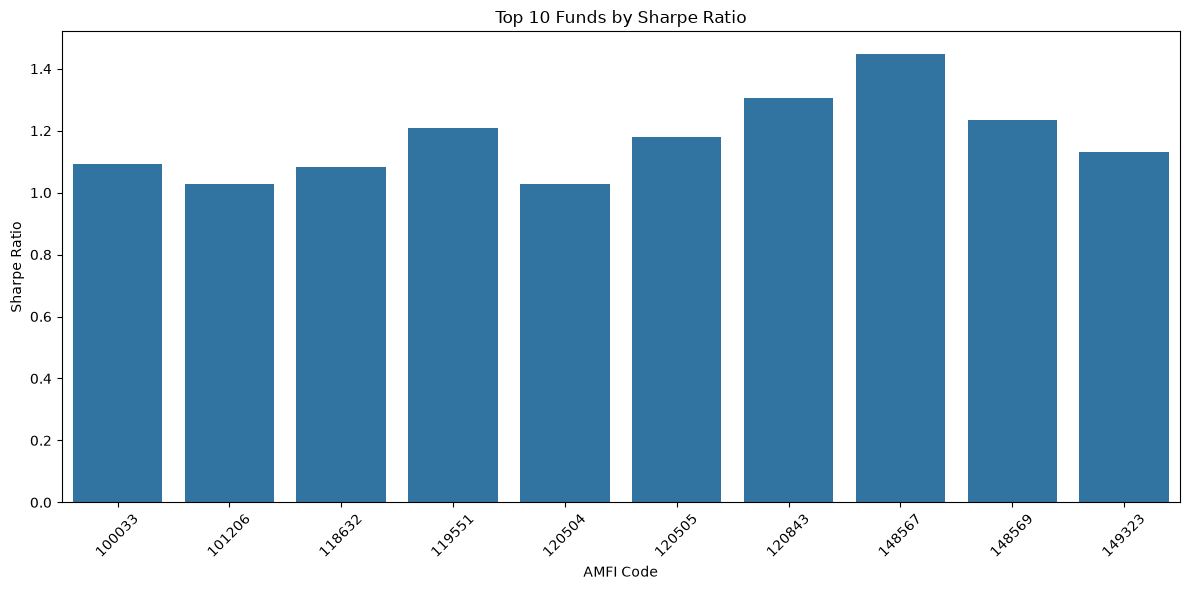

In [12]:
top10 = sharpe_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation: Sharpe Ratio

Funds with higher Sharpe Ratios generated better risk-adjusted returns, indicating superior performance after considering volatility. These funds offered more return for every unit of risk taken by investors.

In [13]:
sortino_list = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    # Only negative returns
    downside_returns = fund_returns[fund_returns < 0]

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (
            (avg_return - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    sortino_list.append([fund, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [14]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


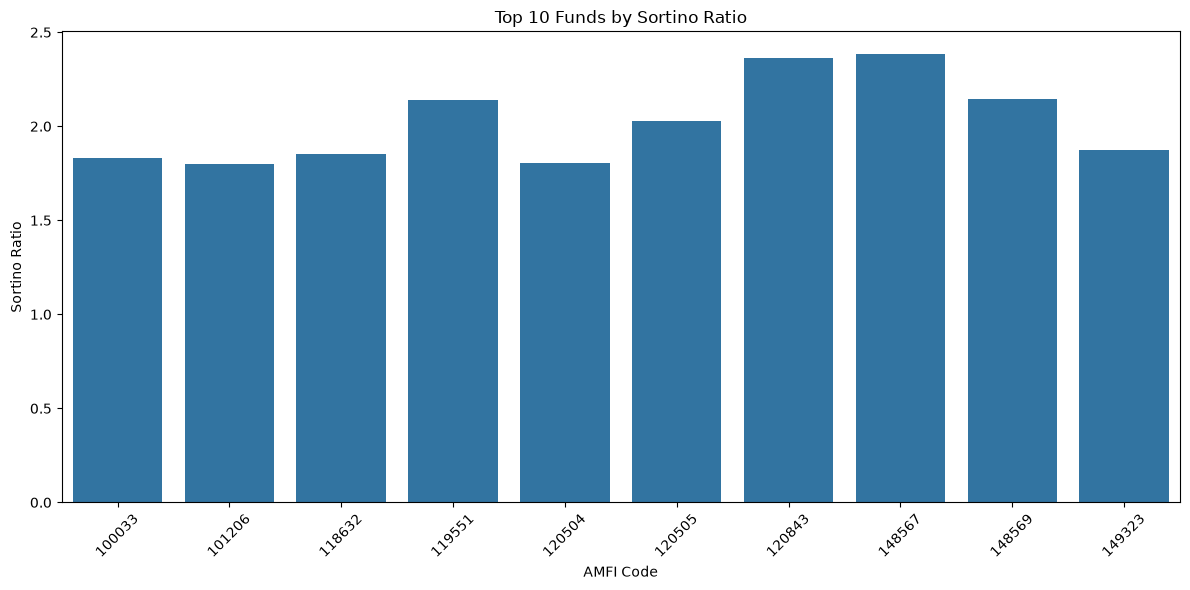

In [15]:
top10 = sortino_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="sortino_ratio"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation: Sortino Ratio

The Sortino Ratio considers only downside volatility, making it a more focused measure of downside risk. Funds with higher Sortino Ratios delivered superior returns while minimizing negative return fluctuations.

In [16]:
# Use NIFTY100 as benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

# Daily benchmark returns
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100[["date", "benchmark_return"]]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [17]:
merged_returns = pd.merge(
    nav_history,
    nifty100,
    on="date",
    how="inner"
)

merged_returns.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [18]:
alpha_beta = []

for fund in merged_returns["amfi_code"].unique():

    fund_data = merged_returns[
        merged_returns["amfi_code"] == fund
    ].dropna()

    if len(fund_data) < 2:
        continue

    regression = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    beta = regression.slope

    alpha = regression.intercept * 252

    alpha_beta.append([
        fund,
        alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [19]:
drawdown_list = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    # Running maximum NAV
    fund_data["running_max"] = fund_data["nav"].cummax()

    # Drawdown
    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
    ) - 1

    max_drawdown = fund_data["drawdown"].min()

    drawdown_list.append([
        fund,
        max_drawdown
    ])

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [20]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    sortino_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    performance[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,expense_ratio_pct
0,100016,2.637074,-0.201517,-0.351047,0.037476,-0.058268,-0.247344,1.55
1,100025,4.458210,-0.567095,-0.941821,0.042818,0.001158,-0.043083,0.56
2,100033,30.123153,1.093699,1.829134,0.271954,0.005104,-0.162172,1.38
3,101206,23.538361,1.027213,1.799563,0.213998,0.021086,-0.112916,1.60
4,101207,7.938765,0.162661,0.276644,0.108971,-0.065289,-0.354469,1.53


In [21]:
scorecard["return_rank"] = scorecard["cagr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

In [22]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 0.30 +

    scorecard["sharpe_rank"] * 0.25 +

    scorecard["alpha_rank"] * 0.20 +

    scorecard["expense_rank"] * 0.15 +

    scorecard["drawdown_rank"] * 0.10

)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard.head(10)

,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
25,120505,32.827406,1.180101,2.029353,0.292636,0.000549,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,6.900
34,148567,30.974108,1.448291,2.385644,0.269838,0.023684,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,7.400
30,120843,30.907455,1.306744,2.364320,0.273305,-0.022830,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,7.900
2,100033,30.123153,1.093699,1.829134,0.271954,0.005104,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,9.600
36,148569,31.949523,1.234930,2.146914,0.282704,0.018134,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,10.325
21,119598,32.423536,0.945308,1.675317,0.303370,-0.023196,-0.287060,1.43,2.0,14.0,1.0,21.0,36.0,11.050
24,120504,23.295119,1.026524,1.805294,0.211948,0.016232,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,12.000
20,119552,21.524236,0.953279,1.609776,0.198686,-0.026159,-0.118035,0.66,15.0,12.0,15.0,4.0,11.0,12.200
39,149324,32.287440,0.949796,1.619793,0.300579,0.011455,-0.311719,1.52,3.0,13.0,2.0,26.5,37.0,12.225
19,119551,25.804686,1.208267,2.140267,0.232010,-0.031751,-0.150124,1.54,10.0,4.0,10.0,30.5,17.0,12.275


In [23]:
top5_funds = scorecard.head(5)["amfi_code"].tolist()

top5_funds

[120505, 148567, 120843, 100033, 148569]

In [24]:
top5_nav = nav_history[
    nav_history["amfi_code"].isin(top5_funds)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [25]:
top5_nav["normalized_nav"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [26]:
# Filter NIFTY50
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50.sort_values("date")

nifty50["normalized_nav"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100


# Filter NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["normalized_nav"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

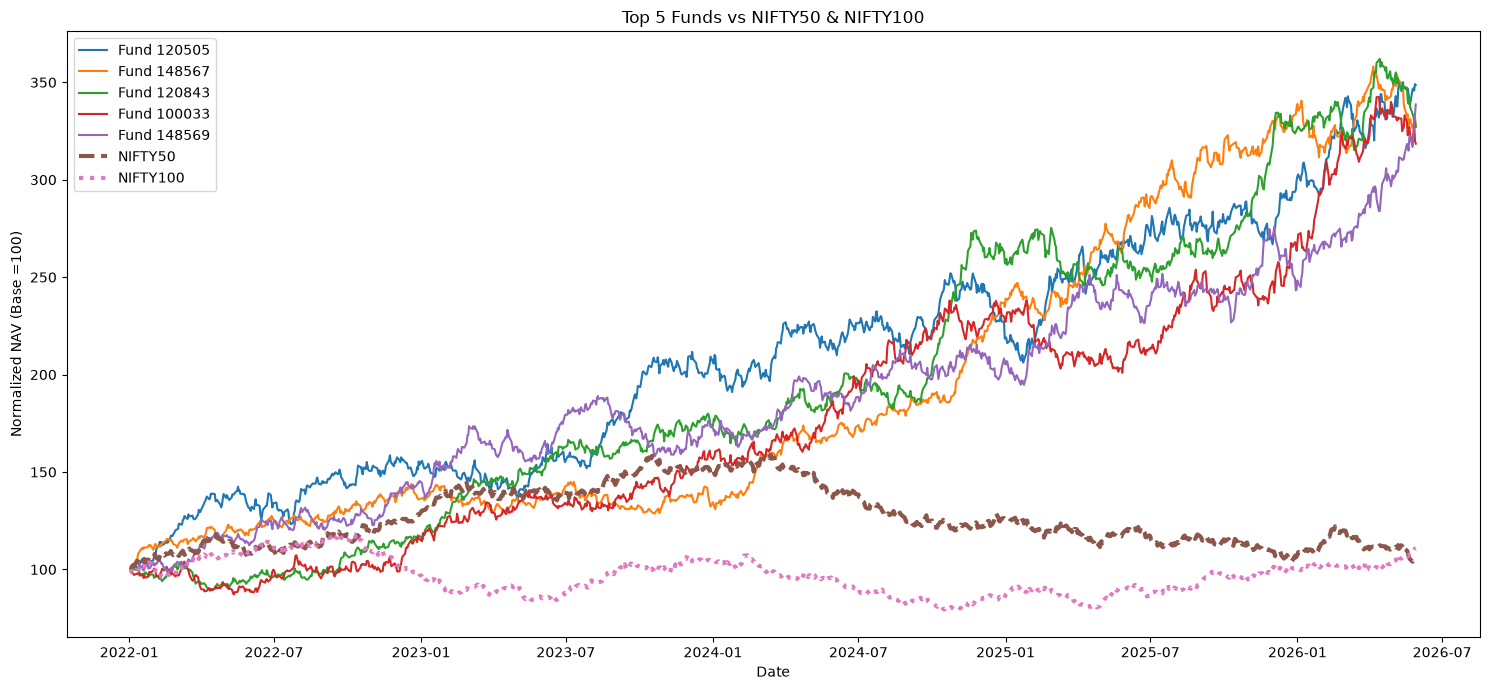

In [27]:
plt.figure(figsize=(15,7))

# Plot Top 5 Funds
for fund in top5_funds:

    temp = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=f"Fund {fund}"
    )

# Plot NIFTY50
plt.plot(
    nifty50["date"],
    nifty50["normalized_nav"],
    label="NIFTY50",
    linewidth=3,
    linestyle="--"
)

# Plot NIFTY100
plt.plot(
    nifty100["date"],
    nifty100["normalized_nav"],
    label="NIFTY100",
    linewidth=3,
    linestyle=":"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("Normalized NAV (Base =100)")

plt.legend()

plt.tight_layout()

plt.show()

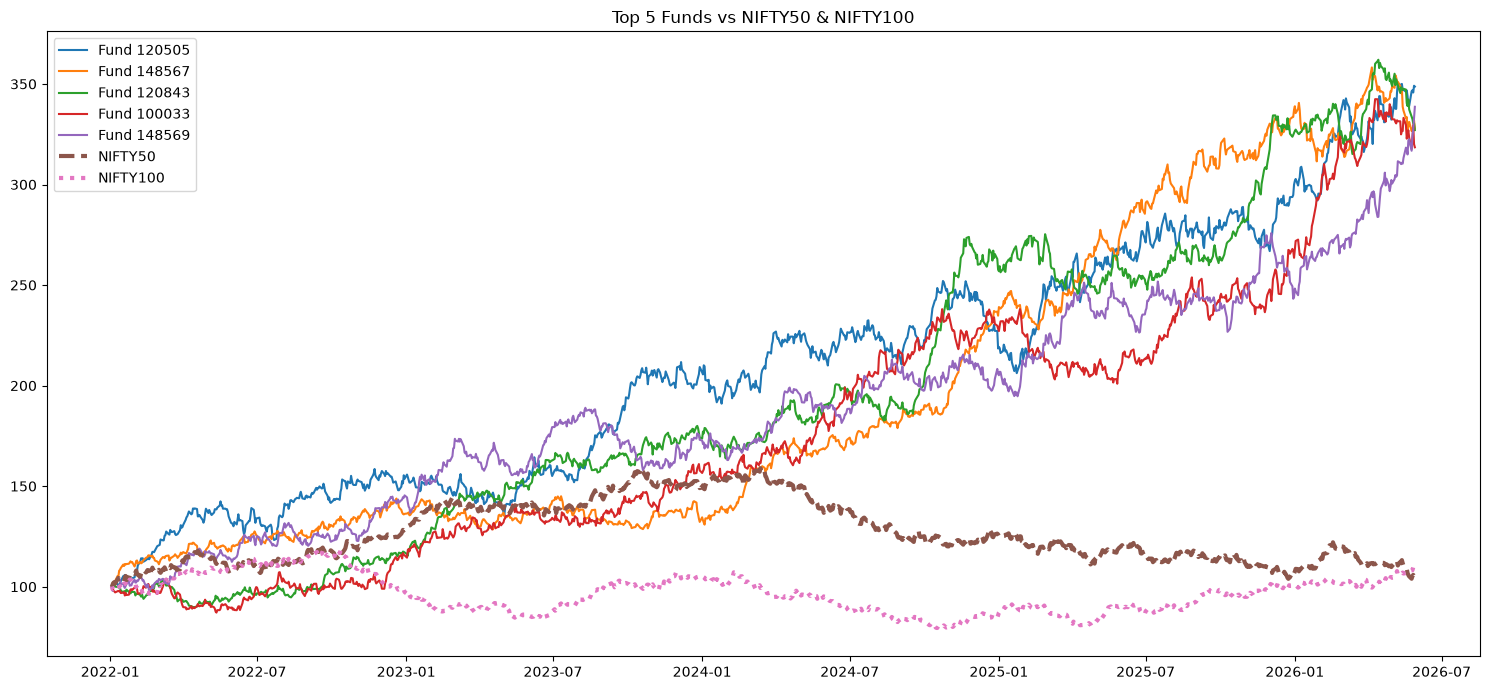

In [28]:
plt.figure(figsize=(15,7))

for fund in top5_funds:

    temp = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=f"Fund {fund}"
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized_nav"],
    label="NIFTY50",
    linewidth=3,
    linestyle="--"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized_nav"],
    label="NIFTY100",
    linewidth=3,
    linestyle=":"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")

plt.legend()

plt.tight_layout()

plt.savefig(
    project_path / "reports" / "benchmark_comparison.png",
    dpi=300
)

plt.show()

In [29]:
scorecard.to_csv(
    project_path / "reports" / "fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    project_path / "reports" / "alpha_beta.csv",
    index=False
)

print("All files exported successfully!")

All files exported successfully!


In [30]:
# Convert weighted rank to a 0–100 score

min_score = scorecard["fund_score"].min()
max_score = scorecard["fund_score"].max()

scorecard["fund_score_100"] = (
    (max_score - scorecard["fund_score"])
    / (max_score - min_score)
) * 100

scorecard["fund_score_100"] = scorecard["fund_score_100"].round(2)

scorecard.head(10)

,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,fund_score_100
25,120505,32.827406,1.180101,2.029353,0.292636,0.000549,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,6.900,100.00
34,148567,30.974108,1.448291,2.385644,0.269838,0.023684,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,7.400,98.29
30,120843,30.907455,1.306744,2.364320,0.273305,-0.022830,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,7.900,96.58
2,100033,30.123153,1.093699,1.829134,0.271954,0.005104,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,9.600,90.78
36,148569,31.949523,1.234930,2.146914,0.282704,0.018134,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,10.325,88.30
21,119598,32.423536,0.945308,1.675317,0.303370,-0.023196,-0.287060,1.43,2.0,14.0,1.0,21.0,36.0,11.050,85.82
24,120504,23.295119,1.026524,1.805294,0.211948,0.016232,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,12.000,82.58
20,119552,21.524236,0.953279,1.609776,0.198686,-0.026159,-0.118035,0.66,15.0,12.0,15.0,4.0,11.0,12.200,81.90
39,149324,32.287440,0.949796,1.619793,0.300579,0.011455,-0.311719,1.52,3.0,13.0,2.0,26.5,37.0,12.225,81.81
19,119551,25.804686,1.208267,2.140267,0.232010,-0.031751,-0.150124,1.54,10.0,4.0,10.0,30.5,17.0,12.275,81.64


In [31]:
scorecard.to_csv(
    project_path / "reports" / "fund_scorecard.csv",
    index=False
)